In [1]:
pip install pybaseball

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.1 MB/s eta 0:00:00


In [2]:
import pybaseball as pyb
from pybaseball import statcast,statcast_batter, playerid_lookup, playerid_reverse_lookup
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import joblib
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#get every pitch from past 5 mlb seasons
from os import stat
statcast_2025_pt2=statcast(start_dt='2025-07-01', end_dt='2025-11-01')
statcast_2025_pt1=statcast(start_dt='2025-03-18', end_dt='2025-06-30')
statcast_2024_pt2=statcast(start_dt='2024-07-01', end_dt='2024-10-30')
statcast_2024_pt1=statcast(start_dt='2024-03-20', end_dt='2024-06-30')
statcast_2023_pt2=statcast(start_dt='2023-07-01', end_dt='2023-11-01')
statcast_2023_pt1=statcast(start_dt='2023-03-20', end_dt='2023-06-30')
statcast_2022_pt2=statcast(start_dt='2022-07-01', end_dt='2022-11-05')
statcast_2022_pt1=statcast(start_dt='2022-04-07', end_dt='2022-06-30')
statcast_2021_pt2=statcast(start_dt='2021-07-01', end_dt='2021-11-02')
statcast_2021_pt1=statcast(start_dt='2021-04-01', end_dt='2021-06-30')

This is a large query, it may take a moment to complete


  0%|          | 0/124 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = 

This is a large query, it may take a moment to complete


  0%|          | 0/105 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = 

This is a large query, it may take a moment to complete


  0%|          | 0/122 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = 

In [ ]:
#save for RAM overload crashes
statcast_2025_pt2.to_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2025_pt2.parquet")
statcast_2025_pt1.to_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2025_pt1.parquet")
statcast_2024_pt2.to_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2024_pt2.parquet")
statcast_2024_pt1.to_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2024_pt1.parquet")
statcast_2023_pt2.to_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2023_pt2.parquet")
statcast_2023_pt1.to_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2023_pt1.parquet")
statcast_2022_pt2.to_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2022_pt2.parquet")
statcast_2022_pt1.to_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2022_pt1.parquet")
statcast_2021_pt2.to_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2021_pt2.parquet")
statcast_2021_pt1.to_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2021_pt1.parquet")

NameError: name 'statcast_2025_pt2' is not defined

In [ ]:
#read in files in case of a RAM overload crash
statcast_2025_pt2=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2025_pt2.parquet", engine='pyarrow')
statcast_2025_pt1=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2025_pt1.parquet", engine='pyarrow')
statcast_2024_pt2=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2024_pt2.parquet", engine='pyarrow')
statcast_2024_pt1=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2024_pt1.parquet", engine='pyarrow')
statcast_2023_pt2=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2023_pt2.parquet", engine='pyarrow')
statcast_2023_pt1=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2023_pt1.parquet", engine='pyarrow')
statcast_2022_pt2=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2022_pt2.parquet", engine='pyarrow')
statcast_2022_pt1=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2022_pt1.parquet", engine='pyarrow')
statcast_2021_pt2=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2021_pt2.parquet", engine='pyarrow')
statcast_2021_pt1=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2021_pt1.parquet", engine='pyarrow')

In [ ]:
#combine partial season files
statcast_2025=pd.concat([statcast_2025_pt1,statcast_2025_pt2],ignore_index=True)
statcast_2024=pd.concat([statcast_2024_pt1,statcast_2024_pt2],ignore_index=True)
statcast_2023=pd.concat([statcast_2023_pt1,statcast_2023_pt2],ignore_index=True)
statcast_2022=pd.concat([statcast_2022_pt1,statcast_2022_pt2],ignore_index=True)
statcast_2021=pd.concat([statcast_2021_pt1,statcast_2021_pt2],ignore_index=True)
statcast_2025.to_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2025.parquet")
statcast_2024.to_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2024.parquet")
statcast_2023.to_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2023.parquet")
statcast_2022.to_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2022.parquet")
statcast_2021.to_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2021.parquet")

In [ ]:
#read in files
statcast_2025=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2025.parquet", engine='pyarrow')
statcast_2024=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2024.parquet", engine='pyarrow')
statcast_2023=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2023.parquet", engine='pyarrow')
statcast_2022=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2022.parquet", engine='pyarrow')
statcast_2021=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/statcast_2021.parquet", engine='pyarrow')

In [ ]:
#get all balls in play from '21-'25
bip_2025=statcast_2025[statcast_2025['type']=='X']
bip_2024=statcast_2024[statcast_2024['type']=='X']
bip_2023=statcast_2023[statcast_2023['type']=='X']
bip_2022=statcast_2022[statcast_2022['type']=='X']
bip_2021=statcast_2021[statcast_2021['type']=='X']
#combine all years of BIP
bip=pd.concat([bip_2025,bip_2024,bip_2023,bip_2022,bip_2021],ignore_index=True)

In [ ]:
#get spray angle from x and y coords of BIP and create RHB dummy
bip['adj_x'] = bip['hc_x'] - 128.4
bip['adj_y'] = 208.2 - bip['hc_y']
bip['spray_angle']=np.arctan2(bip['adj_x'], bip['adj_y']) * (180 / np.pi)
bip['right_batter']=np.where(bip['stand']=='R',1,0)


In [ ]:
#get game year to use for park factors
bip["game_year"] = pd.to_datetime(bip["game_date"]).dt.year
#park factors by year
park_factors_by_year = {
    # 2025
    ("COL", 2025): 1.15, ("ATH", 2025): 1.08, ("DET", 2025): 1.05,
    ("LAD", 2025): 1.04, ("TOR", 2025): 1.03, ("BAL", 2025): 1.03,
    ("BOS", 2025): 1.03, ("TB",  2025): 1.02, ("AZ",  2025): 1.02,
    ("PHI", 2025): 1.02, ("WSH", 2025): 1.01, ("MIN", 2025): 1.01,
    ("ATL", 2025): 1.01, ("LAA", 2025): 1.01, ("CIN", 2025): 0.99,
    ("NYM", 2025): 0.99, ("SF",  2025): 0.99, ("NYY", 2025): 0.99,
    ("MIL", 2025): 0.98, ("CHC", 2025): 0.98, ("CWS", 2025): 0.98,
    ("STL", 2025): 0.97, ("MIA", 2025): 0.97, ("HOU", 2025): 0.97,
    ("KC",  2025): 0.97, ("PIT", 2025): 0.96, ("CLE", 2025): 0.95,
    ("SD",  2025): 0.95, ("SEA", 2025): 0.91, ("TEX", 2025): 0.91,

    # 2024
    ("COL", 2024): 1.10, ("AZ",  2024): 1.06, ("CIN", 2024): 1.05,
    ("MIN", 2024): 1.05, ("MIA", 2024): 1.04, ("NYY", 2024): 1.03,
    ("HOU", 2024): 1.03, ("BAL", 2024): 1.02, ("PIT", 2024): 1.02,
    ("BOS", 2024): 1.02, ("KC",  2024): 1.02, ("CLE", 2024): 1.02,
    ("LAA", 2024): 1.01, ("PHI", 2024): 1.00, ("LAD", 2024): 1.00,
    ("TOR", 2024): 1.00, ("SD",  2024): 0.99, ("NYM", 2024): 0.99,
    ("ATL", 2024): 0.99, ("WSH", 2024): 0.99, ("CWS", 2024): 0.99,
    ("STL", 2024): 0.98, ("ATH", 2024): 0.98, ("DET", 2024): 0.97,
    ("TB",  2024): 0.96, ("SF",  2024): 0.96, ("MIL", 2024): 0.96,
    ("TEX", 2024): 0.95, ("CHC", 2024): 0.91, ("SEA", 2024): 0.89,

    # 2023
    ("COL", 2023): 1.13, ("BOS", 2023): 1.08, ("TEX", 2023): 1.06,
    ("KC",  2023): 1.06, ("WSH", 2023): 1.03, ("ATL", 2023): 1.03,
    ("STL", 2023): 1.03, ("CIN", 2023): 1.02, ("CHC", 2023): 1.01,
    ("MIA", 2023): 1.01, ("LAA", 2023): 1.00, ("MIN", 2023): 1.00,
    ("HOU", 2023): 1.00, ("NYY", 2023): 0.99, ("DET", 2023): 0.99,
    ("CWS", 2023): 0.99, ("AZ",  2023): 0.99, ("LAD", 2023): 0.99,
    ("PHI", 2023): 0.99, ("MIL", 2023): 0.98, ("TB",  2023): 0.98,
    ("PIT", 2023): 0.98, ("NYM", 2023): 0.97, ("TOR", 2023): 0.97,
    ("BAL", 2023): 0.96, ("ATH", 2023): 0.96, ("SD",  2023): 0.96,
    ("CLE", 2023): 0.94, ("SF",  2023): 0.94, ("SEA", 2023): 0.93,

    # 2022
    ("COL", 2022): 1.14, ("BOS", 2022): 1.08, ("CIN", 2022): 1.07,
    ("KC",  2022): 1.05, ("TOR", 2022): 1.03, ("PHI", 2022): 1.03,
    ("TEX", 2022): 1.02, ("WSH", 2022): 1.02, ("LAD", 2022): 1.01,
    ("PIT", 2022): 1.01, ("CWS", 2022): 1.01, ("MIA", 2022): 1.00,
    ("LAA", 2022): 1.00, ("MIN", 2022): 1.00, ("SF",  2022): 1.00,
    ("BAL", 2022): 0.99, ("HOU", 2022): 0.99, ("CHC", 2022): 0.99,
    ("ATL", 2022): 0.99, ("AZ",  2022): 0.98, ("NYY", 2022): 0.98,
    ("STL", 2022): 0.98, ("MIL", 2022): 0.98, ("ATH", 2022): 0.97,
    ("DET", 2022): 0.97, ("TB",  2022): 0.96, ("NYM", 2022): 0.96,
    ("CLE", 2022): 0.96, ("SEA", 2022): 0.93, ("SD",  2022): 0.92,

    # 2021
    ("CIN", 2021): 1.10, ("BAL", 2021): 1.08, ("COL", 2021): 1.08,
    ("BOS", 2021): 1.07, ("WSH", 2021): 1.04, ("AZ",  2021): 1.04,
    ("CHC", 2021): 1.03, ("PIT", 2021): 1.02, ("KC",  2021): 1.02,
    ("PHI", 2021): 1.01, ("CWS", 2021): 1.01, ("MIN", 2021): 1.01,
    ("LAA", 2021): 1.01, ("HOU", 2021): 1.00, ("ATL", 2021): 1.00,
    ("CLE", 2021): 1.00, ("LAD", 2021): 0.99, ("SF",  2021): 0.98,
    ("TEX", 2021): 0.97, ("NYY", 2021): 0.97, ("SD",  2021): 0.97,
    ("MIL", 2021): 0.96, ("NYM", 2021): 0.96, ("DET", 2021): 0.96,
    ("TOR", 2021): 0.95, ("MIA", 2021): 0.94, ("TB",  2021): 0.94,
    ("ATH", 2021): 0.94, ("STL", 2021): 0.93, ("SEA", 2021): 0.92,
}
#add appropriate park factor to each batted ball
bip["park_factor"] = bip.apply(
    lambda row: park_factors_by_year.get((row["home_team"], row["game_year"])),
    axis=1
)

In [ ]:
bip.to_parquet("/content/drive/MyDrive/SwingDecisionModel/bip.parquet")


In [ ]:
bip=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/bip.parquet", engine='pyarrow')

In [ ]:
#assign features and target for BIP model and remove NAs
bip_features=['launch_speed','launch_angle','spray_angle','right_batter','park_factor']
bip_target="delta_run_exp"
subset_bip = bip.dropna(subset=bip_features + [bip_target]).copy()


In [ ]:
#create X and Y subsets
X = subset_bip[bip_features].values
y = subset_bip[bip_target].values

In [ ]:
#model BIP xRV using XGBoost model and cross-validate with 5 fold K-fold cross-validation
kf_bip = KFold(n_splits=5, shuffle=True, random_state=42)
bip_mse_scores = []
#train folds are train_idx, validation fold is val_idx
for fold, (train_idx, val_idx) in enumerate(kf_bip.split(X)):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    bip_model = xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    bip_model.fit(X_train, y_train)
    preds = bip_model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    bip_mse_scores.append(mse)
    #get mse for each fold to evaluate model stability
    print(f"Fold {fold+1} MSE: {mse:.4f}")
#get mean and std MSE for model accuracy and variance
print(f"\nMean MSE: {np.mean(bip_mse_scores):.4f}")
print(f"Std MSE:  {np.std(bip_mse_scores):.4f}")

Fold 1 MSE: 0.1167
Fold 2 MSE: 0.1181
Fold 3 MSE: 0.1196
Fold 4 MSE: 0.1171
Fold 5 MSE: 0.1173

Mean MSE: 0.1177
Std MSE:  0.0010


In [ ]:
#rank model features by importance to determine if any features should be removed/changed
for name, score in zip(bip_features, bip_model.feature_importances_):
    print(f"{name}: {score:.4f}")

In [ ]:
#get R^2 to further evaluate model fit
r2 = r2_score(y_val, preds)
print(f"Fold {fold+1} R²: {r2:.4f}")

In [ ]:
#use model to predict xRV for every BIP
subset_bip["xrv"] = bip_model.predict(subset_bip[bip_features].values)

In [ ]:
subset_bip.to_parquet("/content/drive/MyDrive/SwingDecisionModel/subset_bip.parquet")

In [ ]:
subset_bip=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/subset_bip.parquet", engine='pyarrow')

In [ ]:
#get all swings that did not result in a bip
swings_2025 = statcast_2025.query("description == ['foul_tip','swinging_strike','foul']")
swings_2024 = statcast_2024.query("description == ['foul_tip','swinging_strike','foul']")
swings_2023 = statcast_2023.query("description == ['foul_tip','swinging_strike','foul']")
swings_2022 = statcast_2022.query("description == ['foul_tip','swinging_strike','foul']")
swings_2021 = statcast_2021.query("description == ['foul_tip','swinging_strike','foul']")
swings_no_bip=pd.concat([swings_2025,swings_2024,swings_2023,swings_2022,swings_2021],ignore_index=True)

In [ ]:
swings_no_bip.to_parquet("/content/drive/MyDrive/SwingDecisionModel/swings_no_bip.parquet")

In [ ]:
swings_no_bip=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/swings_no_bip.parquet", engine='pyarrow')

In [ ]:
#add game year to evaluate batter seasons and xRV column to join with BIP data
swings_no_bip["game_year"] = pd.to_datetime(swings_no_bip["game_date"]).dt.year
swings_no_bip['xrv']=swings_no_bip['delta_run_exp']

In [ ]:
#join bip and non-bip swings to prepare for swing model
all_swings=pd.concat([subset_bip,swings_no_bip],ignore_index=True)

,game_year,delta_run_exp,xrv
0,2025,-0.308,-0.256756
1,2025,0.223,0.028469
2,2025,-0.215,0.237093
3,2025,-0.22,-0.142384
4,2025,-0.182,-0.26699
...,...,...,...
1725096,2021,-0.075,-0.075
1725097,2021,-0.068,-0.068
1725098,2021,-0.084,-0.084
1725099,2021,0.0,0.0


In [ ]:
#encode pitch type to use as feature as well as RHH and RHP dummies to account for handedness
le = LabelEncoder()
all_swings["pitch_type_encoded"] = le.fit_transform(all_swings["pitch_type"].astype(str))
all_swings["right_batter"] = (all_swings["stand"] == "R").astype(int)
all_swings["right_thrower"] = (all_swings["p_throws"] == "R").astype(int)

In [ ]:
#get features and target for swing model
swings_features=['pitch_type_encoded','release_speed','release_pos_x','release_pos_z','right_batter','right_thrower','balls','strikes',
                                    'pfx_x','pfx_z','plate_x','plate_z','outs_when_up','vx0','vy0','vz0','ax','ay','az','sz_top','sz_bot',
                                    'effective_speed','release_extension','release_pos_y','spin_axis']
swings_target="xrv"




In [ ]:
#drop NAs from features and target
swings_cleaned = all_swings.dropna(subset=swings_features +[swings_target]).copy()

In [ ]:
all_swings.to_parquet("/content/drive/MyDrive/SwingDecisionModel/all_swings.parquet")

In [ ]:
all_swings=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/all_swings.parquet", engine='pyarrow')

In [ ]:
swings_cleaned=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/swings_cleaned.parquet", engine='pyarrow')

In [ ]:
swings_cleaned.to_parquet("/content/drive/MyDrive/SwingDecisionModel/swings_cleaned.parquet")

NameError: name 'swings_cleaned' is not defined

In [ ]:
#split data
X_swings = swings_cleaned[swings_features].values
y_swings = swings_cleaned[swings_target].values


In [ ]:
#XGBoost model for all swings, using 5 fold K-Fold CV again
kf_swings = KFold(n_splits=5, shuffle=True, random_state=42)
swings_mse_scores = []
#train folds are train_idx, validation fold is val_idx
for fold, (train_idx, val_idx) in enumerate(kf_swings.split(X_swings)):
    X_train, X_val = X_swings[train_idx], X_swings[val_idx]
    y_train, y_val = y_swings[train_idx], y_swings[val_idx]

    swings_model = xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    swings_model.fit(X_train, y_train)
    preds_swings = swings_model.predict(X_val)
    mse_swings = mean_squared_error(y_val, preds_swings)
    swings_mse_scores.append(mse_swings)
    print(f"Fold {fold+1} MSE: {mse_swings:.4f}")
#MSE mean and std for model stability and accuracy
print(f"\nMean MSE: {np.mean(swings_mse_scores):.4f}")
print(f"Std MSE:  {np.std(swings_mse_scores):.4f}")

Fold 1 MSE: 0.0496
Fold 2 MSE: 0.0499
Fold 3 MSE: 0.0493
Fold 4 MSE: 0.0495
Fold 5 MSE: 0.0492

Mean MSE: 0.0495
Std MSE:  0.0002


In [ ]:
#save model for future use
joblib.dump(swings_model, "/content/drive/MyDrive/SwingDecisionModel/swings_model.pkl")

['/content/drive/MyDrive/SwingDecisionModel/swings_model.pkl']

In [ ]:
#load swing model
swings_model = joblib.load("/content/drive/MyDrive/SwingDecisionModel/swings_model.pkl")

In [ ]:
#evaluate feature importance
for name, score in zip(swings_features, swings_model.feature_importances_):
    print(f"{name}: {score:.4f}")

pitch_type_encoded: 0.0236
release_speed: 0.0189
release_pos_x: 0.0169
release_pos_z: 0.0185
right_batter: 0.0572
right_thrower: 0.0261
balls: 0.0448
strikes: 0.1325
pfx_x: 0.0221
pfx_z: 0.0231
plate_x: 0.1465
plate_z: 0.1948
outs_when_up: 0.0210
vx0: 0.0192
vy0: 0.0250
vz0: 0.0189
ax: 0.0184
ay: 0.0151
az: 0.0345
sz_top: 0.0272
sz_bot: 0.0217
effective_speed: 0.0281
release_extension: 0.0156
release_pos_y: 0.0134
spin_axis: 0.0170


In [ ]:
#use model to get predicted xRV for every swing in the dataset
swings_cleaned["xrv_predicted"] = swings_model.predict(swings_cleaned[swings_features].values)

In [ ]:
swings_cleaned.to_parquet("/content/drive/MyDrive/SwingDecisionModel/swings_cleaned.parquet")

In [4]:
swings_cleaned=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/swings_cleaned.parquet", engine='pyarrow')

In [ ]:
#prepare for calculation with take xRV
swings_cleaned['xrv_swing']=swings_cleaned['xrv_predicted']

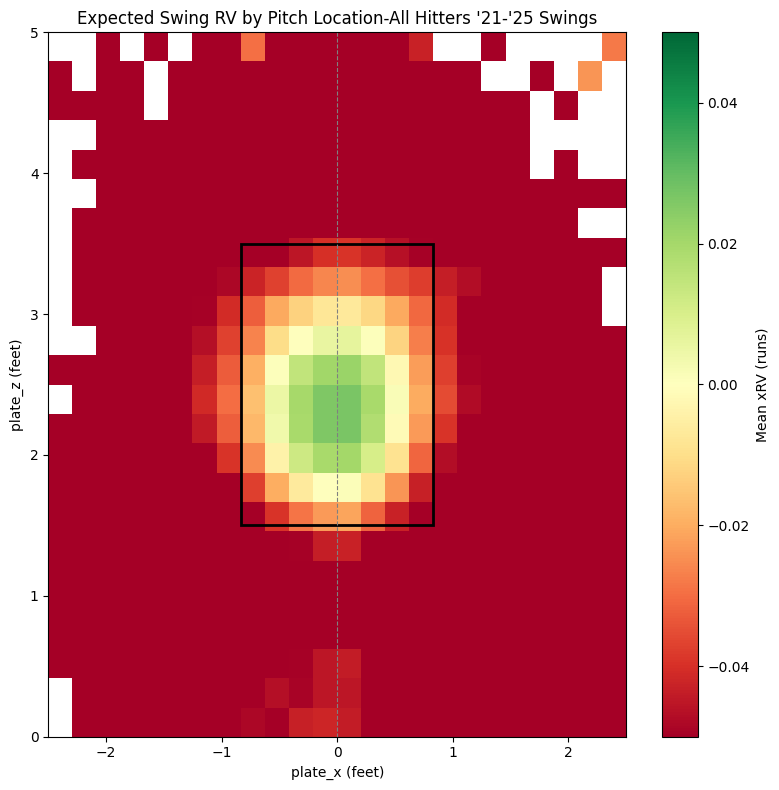

In [8]:
#visualize Swing xRV by location for all hitters
x_bins = np.linspace(-2.5, 2.5, 25)
z_bins = np.linspace(0, 5, 25)

swings_cleaned["x_bin"] = pd.cut(swings_cleaned["plate_x"], bins=x_bins)
swings_cleaned["z_bin"] = pd.cut(swings_cleaned["plate_z"], bins=z_bins)

heatmap = swings_cleaned.groupby(["x_bin", "z_bin"], observed=True)["xrv_predicted"].mean().unstack()

# convert to float and fill empty cells
heatmap = heatmap.astype(float)

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(
    heatmap.T,
    extent=[-2.5, 2.5, 0, 5],
    origin="lower",
    aspect="auto",
    cmap="RdYlGn",
    vmin=-0.05,
    vmax=0.05
)

strike_zone = plt.Rectangle(
    (-0.83, 1.5), 1.66, 2.0,
    linewidth=2, edgecolor="black", facecolor="none"
)
ax.add_patch(strike_zone)

plt.colorbar(im, ax=ax, label="Mean xRV (runs)")
ax.set_xlabel("plate_x (feet)")
ax.set_ylabel("plate_z (feet)")
ax.set_title("Expected Swing RV by Pitch Location-All Hitters '21-'25 Swings")
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

In [ ]:
#get takes from every season and concetenate into one takes table
takes_2025 = statcast_2025.query("description == ['ball','called_strike','blocked_ball','hit_by_pitch']")
takes_2024 = statcast_2024.query("description == ['ball','called_strike','blocked_ball','hit_by_pitch']")
takes_2023 = statcast_2023.query("description == ['ball','called_strike','blocked_ball','hit_by_pitch']")
takes_2022 = statcast_2022.query("description == ['ball','called_strike','blocked_ball','hit_by_pitch']")
takes_2021 = statcast_2021.query("description == ['ball','called_strike','blocked_ball','hit_by_pitch']")
takes_all=pd.concat([takes_2025,takes_2024,takes_2023,takes_2022,takes_2021],ignore_index=True)

In [ ]:
#get game year
takes_all["game_year"] = pd.to_datetime(takes_all["game_date"]).dt.year

In [ ]:
#encode pitch type and create dummy for RHH AND RHP to account for handedness in the take model
le = LabelEncoder()
takes_all["pitch_type_encoded"] = le.fit_transform(takes_all["pitch_type"].astype(str))
takes_all["right_batter"] = (takes_all["stand"] == "R").astype(int)
takes_all["right_thrower"] = (takes_all["p_throws"] == "R").astype(int)

In [ ]:
takes_all.to_parquet("/content/drive/MyDrive/SwingDecisionModel/takes_all.parquet")

In [ ]:
takes_all=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/takes_all.parquet", engine='pyarrow')

In [ ]:
#assign features and target and remove NAs
takes_features=['pitch_type_encoded','release_speed','release_pos_x','release_pos_z','right_batter','right_thrower','balls','strikes',
                                    'pfx_x','pfx_z','plate_x','plate_z','outs_when_up','vx0','vy0','vz0','ax','ay','az','sz_top','sz_bot',
                                    'effective_speed','release_extension','release_pos_y','spin_axis']
takes_target="delta_run_exp"
takes_all = takes_all.dropna(subset=takes_features + [takes_target])

In [ ]:
#split data into features and target
X_takes = takes_all[takes_features].values
y_takes = takes_all[takes_target].values

In [ ]:
#XGBoost model for all takes, using 5 fold K-Fold CV again
kf_takes = KFold(n_splits=5, shuffle=True, random_state=42)
takes_mse_scores = []
#train folds are train_idx, validation fold is val_idx
for fold, (train_idx, val_idx) in enumerate(kf_takes.split(X_takes)):
    X_train, X_val = X_takes[train_idx], X_takes[val_idx]
    y_train, y_val = y_takes[train_idx], y_takes[val_idx]

    takes_model = xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    takes_model.fit(X_train, y_train)
    preds_takes = takes_model.predict(X_val)
    mse_takes = mean_squared_error(y_val, preds_takes)
    takes_mse_scores.append(mse_takes)
    print(f"Fold {fold+1} MSE: {mse_takes:.4f}")
#MSE mean and std for model stability and accuracy
print(f"\nMean MSE: {np.mean(takes_mse_scores):.4f}")
print(f"Std MSE:  {np.std(takes_mse_scores):.4f}")

Fold 1 MSE: 0.0021
Fold 2 MSE: 0.0022
Fold 3 MSE: 0.0022
Fold 4 MSE: 0.0021
Fold 5 MSE: 0.0021

Mean MSE: 0.0021
Std MSE:  0.0000


In [ ]:
#save takes model for future use
joblib.dump(takes_model, "/content/drive/MyDrive/SwingDecisionModel/takes_model.pkl")

['/content/drive/MyDrive/SwingDecisionModel/takes_model.pkl']

In [ ]:
#load takes model
takes_model = joblib.load("/content/drive/MyDrive/takes_model.pkl")

In [ ]:
#model predicts xRV of each take in takes df
takes_all["xrv_take"] = takes_model.predict(takes_all[takes_features].values)

In [ ]:
takes_all.to_parquet("/content/drive/MyDrive/SwingDecisionModel/takes_all.parquet")

In [ ]:
takes_all=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/takes_all.parquet", engine='pyarrow')

In [ ]:
#predict value of taking every pitch that was swung at to find net xRV
swings_cleaned['xrv_take']=takes_model.predict(swings_cleaned[takes_features].values)

In [ ]:
##predict value of swinging at every pitch that was taken to find net xRV
takes_all["xrv_swing"] = swings_model.predict(takes_all[swings_features].values)

In [ ]:
#net xRV of a swing
swings_cleaned['net_rv']=swings_cleaned['xrv_swing']-swings_cleaned['xrv_take']

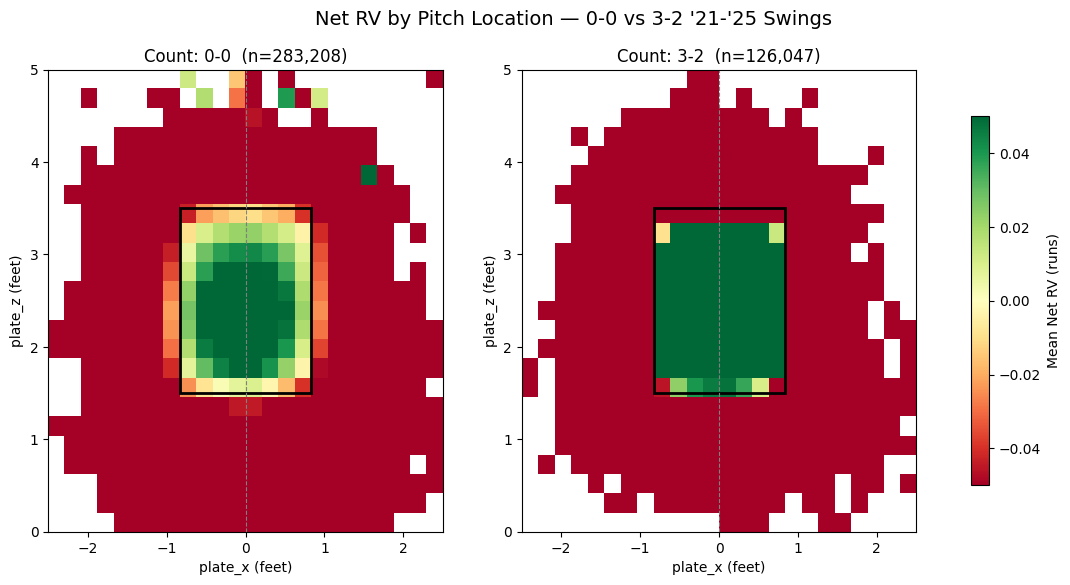

In [ ]:
#compare net xRV of a swing between 0-0 count and 3-2 count
x_bins = np.linspace(-2.5, 2.5, 25)
z_bins = np.linspace(0, 5, 25)

swings_cleaned["x_bin"] = pd.cut(swings_cleaned["plate_x"], bins=x_bins)
swings_cleaned["z_bin"] = pd.cut(swings_cleaned["plate_z"], bins=z_bins)

counts = [(0, 0), (3, 2)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (balls, strikes) in zip(axes, counts):
    subset = swings_cleaned[(swings_cleaned["balls"] == balls) & (swings_cleaned["strikes"] == strikes)]

    heatmap = subset.groupby(["x_bin", "z_bin"], observed=True)["net_rv"].mean().unstack()
    heatmap = heatmap.astype(float)

    im = ax.imshow(
        heatmap.T,
        extent=[-2.5, 2.5, 0, 5],
        origin="lower",
        aspect="auto",
        cmap="RdYlGn",
        vmin=-0.05,
        vmax=0.05
    )

    strike_zone = plt.Rectangle(
        (-0.83, 1.5), 1.66, 2.0,
        linewidth=2, edgecolor="black", facecolor="none"
    )
    ax.add_patch(strike_zone)

    ax.set_xlabel("plate_x (feet)")
    ax.set_ylabel("plate_z (feet)")
    ax.set_title(f"Count: {balls}-{strikes}  (n={len(subset):,})")
    ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

plt.colorbar(im, ax=axes, label="Mean Net RV (runs)", shrink=0.8)
fig.suptitle("Net RV by Pitch Location — 0-0 vs 3-2 '21-'25 Swings", fontsize=14)

plt.subplots_adjust
plt.show()

In [ ]:
#remove spring training swings
swings_cleaned=swings_cleaned[swings_cleaned['game_type']!='S']

In [ ]:
swings_cleaned.to_parquet("/content/drive/MyDrive/SwingDecisionModel/swings_cleaned.parquet")

In [ ]:
#net xRV of all takes
takes_all['net_rv']=takes_all['xrv_take']-takes_all['xrv_swing']

In [ ]:
#remove spring training takes
takes_all=takes_all[takes_all['game_type']!='S']

In [ ]:
takes_all.to_parquet("/content/drive/MyDrive/SwingDecisionModel/takes_all.parquet")

In [ ]:
#get swing xRV/100 grouped by each batter and season to create swing xRV/100 leaderboard
swings_rv = swings_cleaned.groupby(["batter",'game_year']).agg(
    net_rv=("net_rv", "sum"),
    pitches=("net_rv", "count")
).reset_index()

swings_rv["net_rv_per_100"] = (swings_rv["net_rv"] / swings_rv["pitches"]) * 100
all_ids = swings_rv["batter"].unique().tolist()

player_names = playerid_reverse_lookup(all_ids, key_type="mlbam")
player_names["name"] = player_names["name_first"] + " " + player_names["name_last"]
player_names = player_names[["key_mlbam", "name"]]

swings_rv = swings_rv.merge(player_names, left_on="batter", right_on="key_mlbam", how="left").drop(columns="key_mlbam")
swings_rv = swings_rv[swings_rv["pitches"] >= 450]

In [ ]:
#reorder variables and print leaders and laggards
swings_rv = swings_rv[["batter", "name", "game_year", "net_rv","net_rv_per_100",'pitches']]
swings_rv.sort_values(by="net_rv_per_100",ascending=False)

,batter,name,game_year,net_rv,net_rv_per_100,pitches
666,592450,aaron judge,2024,102.394524,7.739571,1323
667,592450,aaron judge,2025,84.535774,7.133821,1185
2820,669743,alex call,2025,30.656607,6.106894,502
163,502054,tommy pham,2025,41.105568,5.757082,714
665,592450,aaron judge,2023,43.762817,5.617820,779
...,...,...,...,...,...,...
792,595879,javier báez,2025,-6.724680,-0.756432,889
271,521692,salvador pérez,2021,-10.866520,-0.795499,1366
791,595879,javier báez,2024,-5.506703,-1.044915,527
789,595879,javier báez,2022,-16.839310,-1.488887,1131


In [ ]:
# Pair each season with the next
swings_rv['next_year'] = swings_rv['game_year'] + 1

# Join current year to next year
paired = swings_rv.merge(
    swings_rv[['batter', 'game_year', 'net_rv_per_100']],
    left_on=['batter', 'next_year'],
    right_on=['batter', 'game_year'],
    suffixes=('_yr1', '_yr2')
)

# Single year-over-year correlation
corr = paired['net_rv_per_100_yr1'].corr(paired['net_rv_per_100_yr2'])
n = len(paired)

print(f"Year-over-Year Correlation: r = {corr:.3f}  (n = {n} batter-season pairs)")

Year-over-Year Correlation: r = 0.776  (n = 1105 batter-season pairs)


In [ ]:
#get take xRV/100 grouped by each batter and season to create take xRV/100 leaderboard
takes_rv = takes_all.groupby(["batter",'game_year']).agg(
    net_rv=("net_rv", "sum"),
    pitches=("net_rv", "count")
).reset_index()
all_ids = takes_rv["batter"].unique().tolist()

player_names = playerid_reverse_lookup(all_ids, key_type="mlbam")
player_names["name"] = player_names["name_first"] + " " + player_names["name_last"]
player_names = player_names[["key_mlbam", "name"]]

takes_rv = takes_rv.merge(player_names, left_on="batter", right_on="key_mlbam", how="left").drop(columns="key_mlbam")
takes_rv["net_rv_per_100"] = (takes_rv["net_rv"] / takes_rv["pitches"]) * 100
takes_rv = takes_rv[takes_rv["pitches"] >= 750]

In [ ]:
#reorder variables and print leaders and laggards
takes_rv = takes_rv[["batter", "name", "game_year", "net_rv", "net_rv_per_100", "pitches"]]
takes_rv.sort_values(by="net_rv_per_100",ascending=False)

,batter,name,game_year,net_rv,net_rv_per_100,pitches
1076,608369,corey seager,2023,92.890045,9.686136,959
449,547180,bryce harper,2023,103.445793,9.327844,1109
2138,663656,kyle tucker,2022,106.653320,9.030764,1181
113,474832,brandon belt,2021,73.887970,8.977882,823
448,547180,bryce harper,2022,71.725647,8.976927,799
...,...,...,...,...,...,...
617,578428,jose iglesias,2025,32.072433,4.242385,756
2251,664058,david fletcher,2021,48.303455,4.121455,1172
3646,695578,james wood,2025,69.804581,4.044298,1726
3523,687401,joey ortiz,2025,42.096283,4.020657,1047


In [ ]:
# Pair each season with the next
takes_rv['next_year'] = takes_rv['game_year'] + 1

# Join current year to next year
paired = takes_rv.merge(
    takes_rv[['batter', 'game_year', 'net_rv_per_100']],
    left_on=['batter', 'next_year'],
    right_on=['batter', 'game_year'],
    suffixes=('_yr1', '_yr2')
)

# Single year-over-year correlation
corr = paired['net_rv_per_100_yr1'].corr(paired['net_rv_per_100_yr2'])
n = len(paired)

print(f"Year-over-Year Correlation: r = {corr:.3f}  (n = {n} batter-season pairs)")

Year-over-Year Correlation: r = 0.756  (n = 1156 batter-season pairs)


n=  100: r = 0.542 [0.338, 0.706]
n=  150: r = 0.567 [0.318, 0.712]
n=  200: r = 0.648 [0.459, 0.818]
n=  250: r = 0.701 [0.578, 0.801]
n=  300: r = 0.751 [0.622, 0.842]
n=  350: r = 0.760 [0.644, 0.843]
n=  400: r = 0.777 [0.663, 0.854]
n=  450: r = 0.795 [0.673, 0.874]
n=  500: r = 0.826 [0.737, 0.894]
n=  600: r = 0.846 [0.749, 0.908]
n=  750: r = 0.859 [0.758, 0.918]
n= 1000: r = 0.893 [0.838, 0.937]

Metric becomes reliable (r=0.70) at ~249 swings


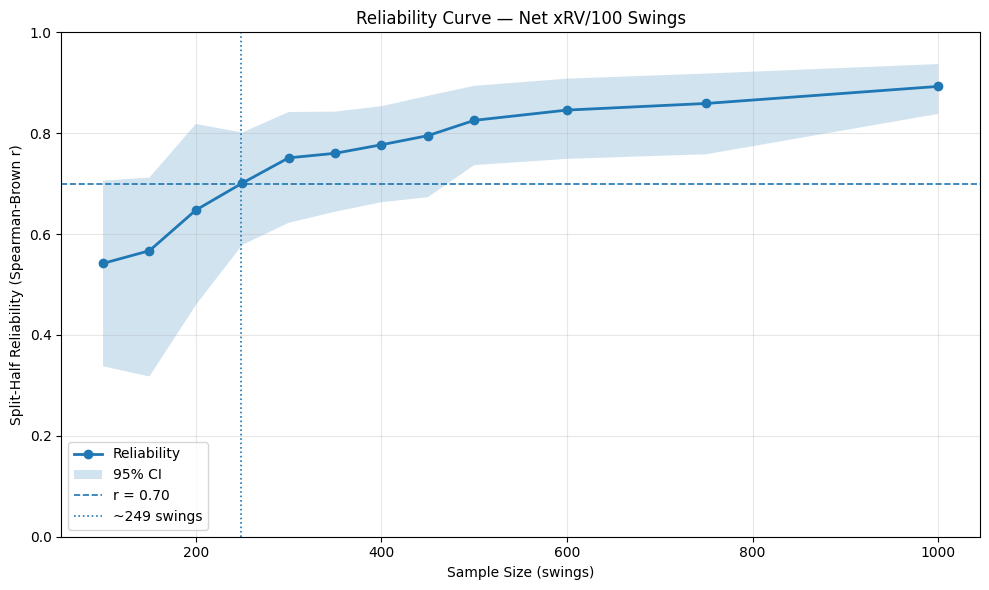

In [ ]:
#get Spearman-Brown reliability coefficients for different swing thresholds to determine how many swings xRV/100 needs to become reliable
np.random.seed(42)

n_splits = 75

batters = swings_cleaned['batter'].unique()
sampled_batters = np.random.choice(batters, size=100, replace=False)
subset = swings_cleaned[swings_cleaned['batter'].isin(sampled_batters)]

grouped = list(subset.groupby('batter'))

sample_sizes = list(range(100, 501, 50)) + [600, 750, 1000]

means, lower, upper = [], [], []

for n in sample_sizes:
    corrs = np.empty(n_splits)
    valid_count = 0

    for split in range(n_splits):
        half1 = []
        half2 = []

        for _, group in grouped:
            if len(group) < n:
                continue

            sample = group.sample(n)

            mid = n // 2
            half1.append(sample.iloc[:mid]['net_rv'].mean())
            half2.append(sample.iloc[mid:]['net_rv'].mean())

        if len(half1) >= 10:
            r = np.corrcoef(half1, half2)[0, 1]
            corrs[valid_count] = (2 * r) / (1 + r)  # Spearman-Brown
            valid_count += 1

    if valid_count == 0:
        means.append(np.nan)
        lower.append(np.nan)
        upper.append(np.nan)
        continue

    corrs = corrs[:valid_count]

    means.append(corrs.mean())
    lower.append(np.percentile(corrs, 2.5))
    upper.append(np.percentile(corrs, 97.5))

    print(f"n={n:>5}: r = {means[-1]:.3f} [{lower[-1]:.3f}, {upper[-1]:.3f}]")

means_arr = np.array(means)
sizes_arr = np.array(sample_sizes)

means_arr = np.maximum.accumulate(means_arr)

idx = np.where(means_arr >= 0.70)[0][0]

if idx == 0:
    crossover = sizes_arr[0]
else:
    x0, x1 = sizes_arr[idx-1], sizes_arr[idx]
    y0, y1 = means_arr[idx-1], means_arr[idx]
    crossover = x0 + (0.70 - y0) * (x1 - x0) / (y1 - y0)

print(f"\nMetric becomes reliable (r=0.70) at ~{int(crossover)} swings")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sample_sizes, means_arr, marker='o', linewidth=2, label='Reliability')
ax.fill_between(sample_sizes, lower, upper, alpha=0.2, label='95% CI')
ax.axhline(0.70, linestyle='--', linewidth=1.2, label='r = 0.70')
ax.axvline(crossover, linestyle=':', linewidth=1.2, label=f'~{int(crossover)} swings')

ax.set_xlabel("Sample Size (swings)")
ax.set_ylabel("Split-Half Reliability (Spearman-Brown r)")
ax.set_title("Reliability Curve — Net xRV/100 Swings")
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n=  100: r = 0.436 [0.142, 0.658]
n=  150: r = 0.404 [-0.009, 0.643]
n=  200: r = 0.537 [0.272, 0.702]
n=  250: r = 0.590 [0.398, 0.708]
n=  300: r = 0.530 [0.169, 0.722]
n=  350: r = 0.553 [0.217, 0.770]
n=  400: r = 0.623 [0.380, 0.783]
n=  450: r = 0.623 [0.370, 0.771]
n=  500: r = 0.662 [0.457, 0.812]
n=  600: r = 0.714 [0.586, 0.831]
n=  750: r = 0.763 [0.616, 0.855]
n= 1000: r = 0.828 [0.730, 0.908]

Metric becomes reliable (r=0.70) at ~572 takes


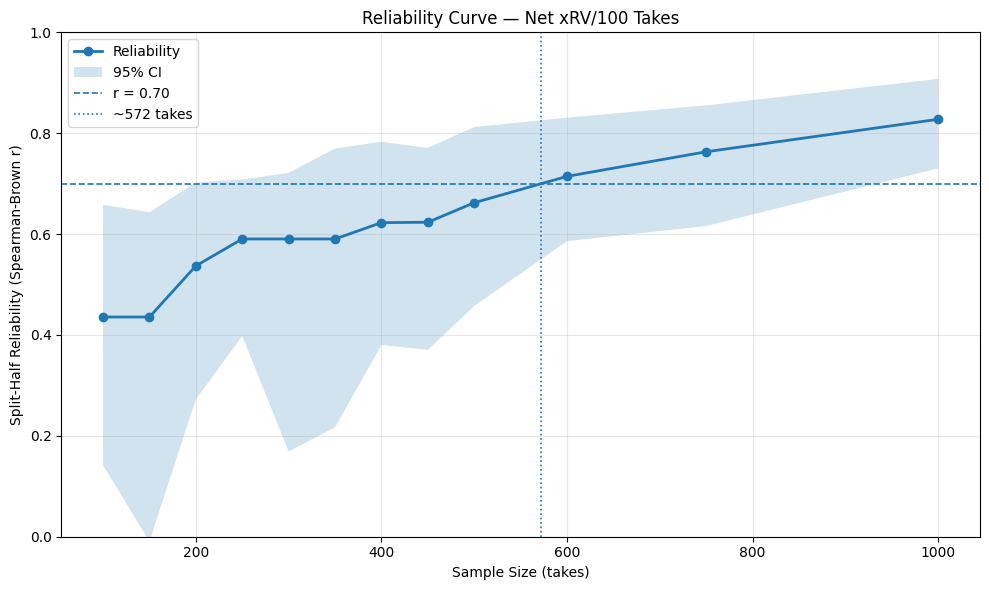

In [ ]:
#get Spearman-Brown reliability coefficients for different take thresholds to determine how many takes xRV/100 needs to become reliable
np.random.seed(42)

n_splits = 75

batters = takes_all['batter'].unique()
sampled_batters = np.random.choice(batters, size=100, replace=False)
subset = takes_all[takes_all['batter'].isin(sampled_batters)]

grouped = list(subset.groupby('batter'))

sample_sizes = list(range(100, 501, 50)) + [600, 750, 1000]

means, lower, upper = [], [], []

for n in sample_sizes:
    corrs = np.empty(n_splits)
    valid_count = 0

    for split in range(n_splits):
        half1 = []
        half2 = []

        for _, group in grouped:
            if len(group) < n:
                continue

            sample = group.sample(n)

            mid = n // 2
            half1.append(sample.iloc[:mid]['net_rv'].mean())
            half2.append(sample.iloc[mid:]['net_rv'].mean())

        if len(half1) >= 10:
            r = np.corrcoef(half1, half2)[0, 1]
            corrs[valid_count] = (2 * r) / (1 + r)  # Spearman-Brown
            valid_count += 1

    if valid_count == 0:
        means.append(np.nan)
        lower.append(np.nan)
        upper.append(np.nan)
        continue

    corrs = corrs[:valid_count]

    means.append(corrs.mean())
    lower.append(np.percentile(corrs, 2.5))
    upper.append(np.percentile(corrs, 97.5))

    print(f"n={n:>5}: r = {means[-1]:.3f} [{lower[-1]:.3f}, {upper[-1]:.3f}]")

means_arr = np.array(means)
sizes_arr = np.array(sample_sizes)

means_arr = np.maximum.accumulate(means_arr)

idx = np.where(means_arr >= 0.70)[0][0]

if idx == 0:
    crossover = sizes_arr[0]
else:
    x0, x1 = sizes_arr[idx-1], sizes_arr[idx]
    y0, y1 = means_arr[idx-1], means_arr[idx]
    crossover = x0 + (0.70 - y0) * (x1 - x0) / (y1 - y0)

print(f"\nMetric becomes reliable (r=0.70) at ~{int(crossover)} takes")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sample_sizes, means_arr, marker='o', linewidth=2, label='Reliability')
ax.fill_between(sample_sizes, lower, upper, alpha=0.2, label='95% CI')
ax.axhline(0.70, linestyle='--', linewidth=1.2, label='r = 0.70')
ax.axvline(crossover, linestyle=':', linewidth=1.2, label=f'~{int(crossover)} takes')

ax.set_xlabel("Sample Size (takes)")
ax.set_ylabel("Split-Half Reliability (Spearman-Brown r)")
ax.set_title("Reliability Curve — Net xRV/100 Takes")
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#find Andrew Vaughn's player id
player_names = playerid_reverse_lookup([683734], key_type="mlbam")
player_names[["key_mlbam", "name_first", "name_last"]]

,key_mlbam,name_first,name_last
0,683734,andrew,vaughn


In [ ]:
#get all swings for Vaughn
vaughn_swings=swings_cleaned[swings_cleaned['batter']==683734].copy()

In [ ]:
vaughn_swings = vaughn_swings.drop(columns=["x_bin", "z_bin"], errors="ignore")
vaughn_swings.to_parquet("/content/drive/MyDrive/SwingDecisionModel/vaughn_swings.parquet")

In [ ]:
#get all takes for Vaughn
vaughn_takes=takes_all[takes_all['batter']==683734].copy()

In [ ]:
vaughn_takes = vaughn_takes.drop(columns=["x_bin", "z_bin"], errors="ignore")
vaughn_takes.to_parquet("/content/drive/MyDrive/SwingDecisionModel/vaughn_takes.parquet")

In [ ]:
#Split 2025 into Brewers and White Sox by date and split all other years by full season
def get_season(row):
    date = pd.to_datetime(row["game_date"])
    year = date.year

    if year == 2025:
        if pd.Timestamp("2025-03-27") <= date <= pd.Timestamp("2025-05-21"):
            return "2025_sox"
        elif pd.Timestamp("2025-07-07") <= date <= pd.Timestamp("2025-10-17"):
            return "2025_brew"
        else:
            return "2025_other"
    else:
        return str(year)

vaughn_swings["season"] = vaughn_swings.apply(get_season, axis=1)
vaughn_takes["season"] = vaughn_takes.apply(get_season, axis=1)

In [ ]:
#make sure 2025 is split and all seasons are accounted for
vaughn_takes['season'].unique()

array(['2025_sox', '2025_brew', '2024', '2023', '2022', '2021'],
      dtype=object)

In [ ]:
#get Vaughn Swing xRV/100 by season including split season
vaughn_swings_rv = vaughn_swings.groupby(["batter",'season']).agg(
    net_rv=("net_rv", "sum"),
    pitches=("net_rv", "count")
).reset_index()

vaughn_swings_rv["net_rv_per_100"] = (vaughn_swings_rv["net_rv"] / vaughn_swings_rv["pitches"]) * 100


In [ ]:
#show swing xRV/100 by season in ranked order
vaughn_swings_rv.sort_values(by="net_rv_per_100",ascending=False)

,batter,season,net_rv,pitches,net_rv_per_100
4,683734,2025_brew,15.953522,469,3.401604
2,683734,2023,18.599916,1073,1.733450
1,683734,2022,16.040485,955,1.679632
3,683734,2024,14.193886,1139,1.246171
5,683734,2025_sox,3.766274,370,1.017912
0,683734,2021,4.510667,805,0.560331


In [ ]:
#find what % of swings were positive and negative xRV decisions
vaughn_swings["pos_rv"] = vaughn_swings["net_rv"] > 0
vaughn_swings["neg_rv"] = vaughn_swings["net_rv"] < 0

vaughn_swings_pos_neg = vaughn_swings.groupby(["season"]).agg(
    pos_rv=("pos_rv", "sum"),
    neg_rv=("neg_rv", "sum"),
    pitches=("net_rv", "count")
).reset_index()

vaughn_swings_pos_neg["pct_pos"] = (vaughn_swings_pos_neg["pos_rv"] / vaughn_swings_pos_neg["pitches"] * 100).round(1)
vaughn_swings_pos_neg["pct_neg"] = (vaughn_swings_pos_neg["neg_rv"] / vaughn_swings_pos_neg["pitches"] * 100).round(1)

vaughn_swings_pos_neg.sort_values(by="pct_pos",ascending=False)

,season,pos_rv,neg_rv,pitches,pct_pos,pct_neg
4,2025_brew,324,145,469,69.1,30.9
2,2023,652,421,1073,60.8,39.2
3,2024,686,453,1139,60.2,39.8
1,2022,567,388,955,59.4,40.6
0,2021,477,328,805,59.3,40.7
5,2025_sox,216,154,370,58.4,41.6


In [ ]:
#get take xRV/100 split by partial season
vaughn_takes_rv = vaughn_takes.groupby(["batter",'season']).agg(
    net_rv=("net_rv", "sum"),
    pitches=("net_rv", "count")
).reset_index()

vaughn_takes_rv["net_rv_per_100"] = (vaughn_takes_rv["net_rv"] / vaughn_takes_rv["pitches"]) * 100

In [ ]:
#show ranked leaderboard
vaughn_takes_rv.sort_values(by="net_rv_per_100",ascending=False)

,batter,season,net_rv,pitches,net_rv_per_100
5,683734,2025_sox,25.048515,381,6.574413
2,683734,2023,76.344635,1209,6.314693
4,683734,2025_brew,37.382881,597,6.261789
3,683734,2024,73.532928,1181,6.226328
0,683734,2021,58.133545,980,5.931994
1,683734,2022,58.208195,1105,5.267710


In [ ]:
#split data from Vaughn's swings to prep for individual model, using same features and target as league-wide swing model
X_vaughn_swings = vaughn_swings[swings_features].values
y_vaughn_swings = vaughn_swings[swings_target].values

In [ ]:
#model Vaughn's swing xRV's using XGBoost and 5 fold K-fold CV, only for visualization purposes
kf_swings = KFold(n_splits=5, shuffle=True, random_state=42)
vaughn_swings_mse_scores = []
#train folds are train_idx, validation fold is val_idx
for fold, (train_idx, val_idx) in enumerate(kf_swings.split(X_vaughn_swings)):
    X_train, X_val = X_vaughn_swings[train_idx], X_vaughn_swings[val_idx]
    y_train, y_val = y_vaughn_swings[train_idx], y_vaughn_swings[val_idx]

    vaughn_swings_model = xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    vaughn_swings_model.fit(X_train, y_train)
    preds_swings_vaughn = vaughn_swings_model.predict(X_val)
    mse_swings_vaughn = mean_squared_error(y_val, preds_swings_vaughn)
    vaughn_swings_mse_scores.append(mse_swings_vaughn)
    print(f"Fold {fold+1} MSE: {mse_swings_vaughn:.4f}")

print(f"\nMean MSE: {np.mean(vaughn_swings_mse_scores):.4f}")
print(f"Std MSE:  {np.std(vaughn_swings_mse_scores):.4f}")

Fold 1 MSE: 0.0646
Fold 2 MSE: 0.0532
Fold 3 MSE: 0.0545
Fold 4 MSE: 0.0555
Fold 5 MSE: 0.0530

Mean MSE: 0.0561
Std MSE:  0.0043


In [ ]:
#save model
joblib.dump(vaughn_swings_model, "/content/drive/MyDrive/SwingDecisionModel/vaughn_swings_model.pkl")

['/content/drive/MyDrive/SwingDecisionModel/vaughn_swings_model.pkl']

In [ ]:
#use model to assign each swing an xRV based on Vaughn's profile, use only for visualization purposes
vaughn_swings["xrv_individual_swings"] = vaughn_swings_model.predict(vaughn_swings[swings_features].values)

In [ ]:
#split data for Vaughn's takes, using same features and target as league-wide take model
X_vaughn_takes = vaughn_takes[takes_features].values
y_vaughn_takes = vaughn_takes[takes_target].values

In [ ]:
#model Vaughn's take xRV's using XGBoost and 5 fold K-fold CV, only for visualization purposes
kf_takes = KFold(n_splits=5, shuffle=True, random_state=42)
vaughn_takes_mse_scores = []
#train folds are train_idx, validation fold is val_idx
for fold, (train_idx, val_idx) in enumerate(kf_takes.split(X_vaughn_takes)):
    X_train, X_val = X_vaughn_takes[train_idx], X_vaughn_takes[val_idx]
    y_train, y_val = y_vaughn_takes[train_idx], y_vaughn_takes[val_idx]

    vaughn_takes_model = xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    vaughn_takes_model.fit(X_train, y_train)
    vaughn_preds_takes = vaughn_takes_model.predict(X_val)
    vaughn_mse_takes = mean_squared_error(y_val, vaughn_preds_takes)
    vaughn_takes_mse_scores.append(vaughn_mse_takes)
    print(f"Fold {fold+1} MSE: {vaughn_mse_takes:.4f}")

print(f"\nMean MSE: {np.mean(vaughn_takes_mse_scores):.4f}")
print(f"Std MSE:  {np.std(vaughn_takes_mse_scores):.4f}")

Fold 1 MSE: 0.0023
Fold 2 MSE: 0.0019
Fold 3 MSE: 0.0019
Fold 4 MSE: 0.0015
Fold 5 MSE: 0.0024

Mean MSE: 0.0020
Std MSE:  0.0003


In [ ]:
##use model to assign each take an xRV based on Vaughn's profile, use only for visualization purposes
vaughn_takes["xrv_individual_takes"] = vaughn_takes_model.predict(vaughn_takes[takes_features].values)

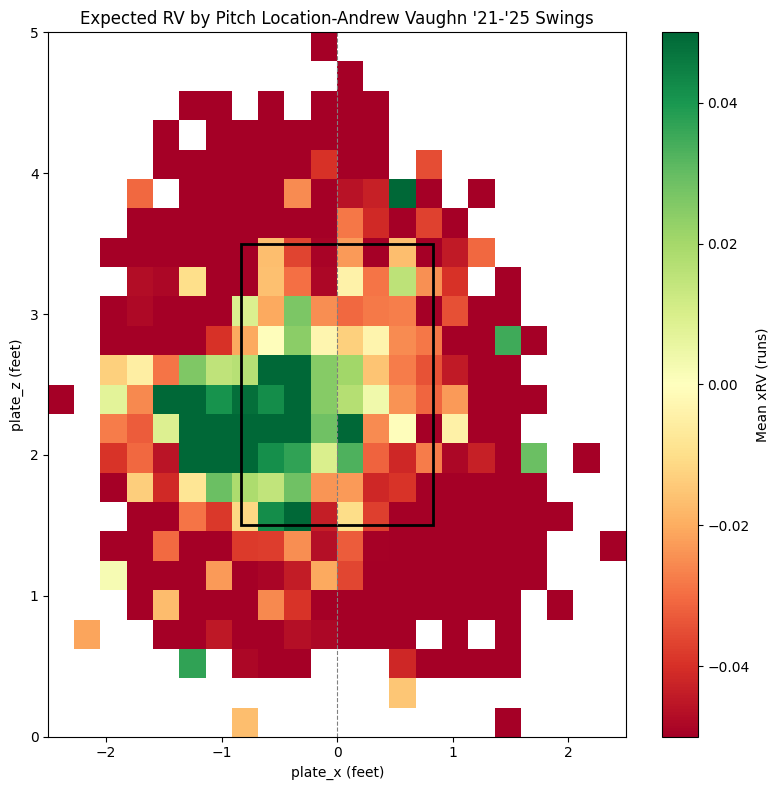

In [ ]:
#visualize player-level swing xRV of all of Vaughn's swings
x_bins = np.linspace(-2.5, 2.5, 25)
z_bins = np.linspace(0, 5, 25)

vaughn_swings["x_bin"] = pd.cut(vaughn_swings["plate_x"], bins=x_bins)
vaughn_swings["z_bin"] = pd.cut(vaughn_swings["plate_z"], bins=z_bins)

heatmap = vaughn_swings.groupby(["x_bin", "z_bin"], observed=True)["xrv_individual_swings"].mean().unstack()

# convert to float and fill empty cells
heatmap = heatmap.astype(float)

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(
    heatmap.T,
    extent=[-2.5, 2.5, 0, 5],
    origin="lower",
    aspect="auto",
    cmap="RdYlGn",
    vmin=-0.05,
    vmax=0.05
)

strike_zone = plt.Rectangle(
    (-0.83, 1.5), 1.66, 2.0,
    linewidth=2, edgecolor="black", facecolor="none"
)
ax.add_patch(strike_zone)

plt.colorbar(im, ax=ax, label="Mean xRV (runs)")
ax.set_xlabel("plate_x (feet)")
ax.set_ylabel("plate_z (feet)")
ax.set_title("Expected RV by Pitch Location-Andrew Vaughn '21-'25 Swings")
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

In [ ]:
#add take xRV for all swings
vaughn_swings["xrv_individual_takes"] = vaughn_takes_model.predict(vaughn_swings[takes_features].values)

In [ ]:
#add swing xRV for all takes
vaughn_takes["xrv_individual_swings"] = vaughn_swings_model.predict(vaughn_takes[swings_features].values)

In [ ]:
#calculate net xRV for all swings
vaughn_swings['xrv_individual_net']=vaughn_swings['xrv_individual_swings']-vaughn_swings['xrv_individual_takes']

In [ ]:
#calculate net xRV for all takes
vaughn_takes['xrv_individual_net']=vaughn_takes['xrv_individual_takes']-vaughn_takes['xrv_individual_swings']

In [ ]:
vaughn_swings = vaughn_swings.drop(columns=["x_bin", "z_bin"], errors="ignore")
vaughn_swings.to_parquet("/content/drive/MyDrive/SwingDecisionModel/vaughn_swings.parquet")

In [ ]:
vaughn_swings=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/vaughn_swings.parquet", engine='pyarrow')

In [ ]:
vaughn_takes = vaughn_takes.drop(columns=["x_bin", "z_bin"], errors="ignore")
vaughn_takes.to_parquet("/content/drive/MyDrive/SwingDecisionModel/vaughn_takes.parquet")

NameError: name 'vaughn_takes' is not defined

In [ ]:
vaughn_takes=pd.read_parquet("/content/drive/MyDrive/SwingDecisionModel/vaughn_takes.parquet", engine='pyarrow')

In [ ]:
#split 2025 swing data into brewers and white sox
vaughn_sox=vaughn_swings[vaughn_swings['season']=='2025_sox'].copy()
vaughn_brew=vaughn_swings[vaughn_swings['season']=='2025_brew'].copy()

In [ ]:
#split 2025 take data into brewers and white sox
vaughn_sox_takes=vaughn_takes[vaughn_takes['season']=='2025_sox'].copy()
vaughn_brew_takes=vaughn_takes[vaughn_takes['season']=='2025_brew'].copy()

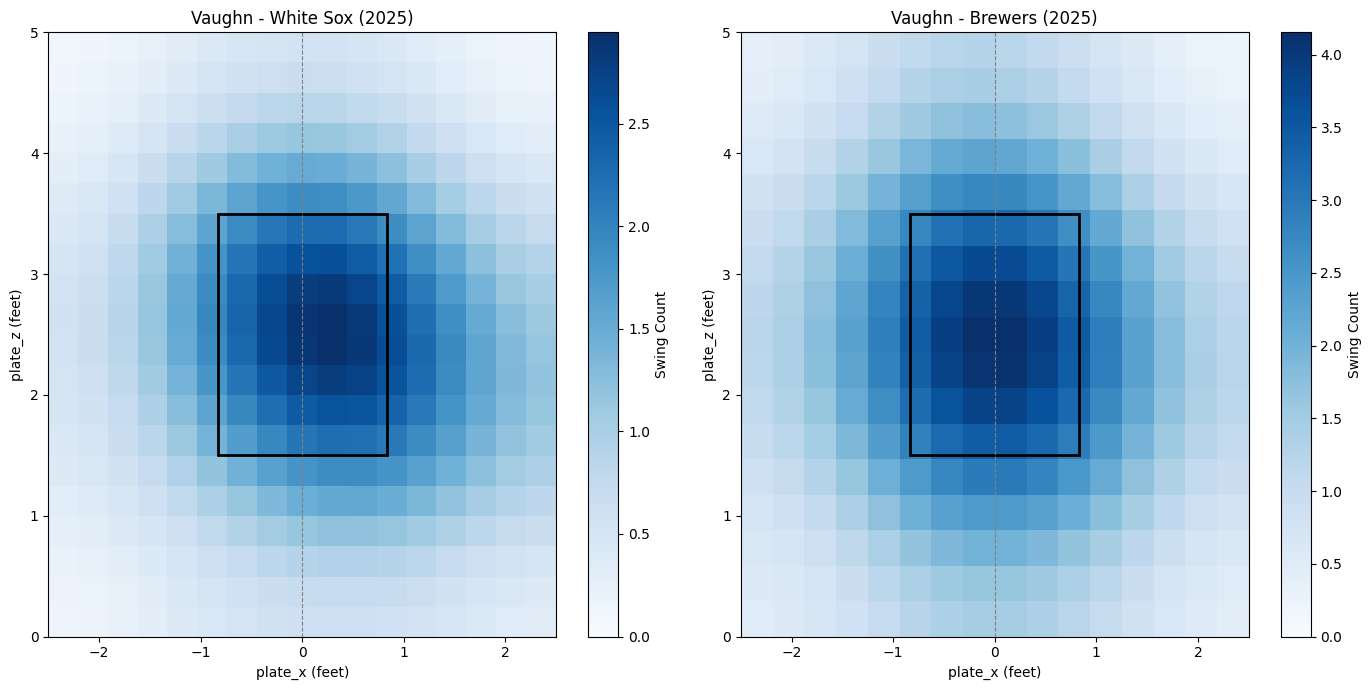

In [ ]:
#visualize swing frequency by location for all counts with heatmap
ig, axes = plt.subplots(1, 2, figsize=(14, 7))

datasets = [
    (vaughn_sox, "Vaughn - White Sox (2025)"),
    (vaughn_brew, "Vaughn - Brewers (2025)")
]

x_bins = np.linspace(-2.5, 2.5, 25)
z_bins = np.linspace(0, 5, 25)

for ax, (data, title) in zip(axes, datasets):
    plot_df = data.copy()
    plot_df["x_bin"] = pd.cut(plot_df["plate_x"], bins=x_bins)
    plot_df["z_bin"] = pd.cut(plot_df["plate_z"], bins=z_bins)

    heatmap = plot_df.groupby(["x_bin", "z_bin"], observed=True)["plate_x"].count().unstack().astype(float)

    smoothed = gaussian_filter(heatmap.fillna(0).T.values, sigma=3)

    im = ax.imshow(
        smoothed,
        extent=[-2.5, 2.5, 0, 5],
        origin="lower",
        aspect="auto",
        cmap="Blues",
        vmin=0
    )

    strike_zone = plt.Rectangle(
        (-0.83, 1.5), 1.66, 2.0,
        linewidth=2, edgecolor="black", facecolor="none"
    )
    ax.add_patch(strike_zone)

    plt.colorbar(im, ax=ax, label="Swing Count")
    ax.set_xlabel("plate_x (feet)")
    ax.set_ylabel("plate_z (feet)")
    ax.set_title(title)
    ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

In [ ]:
#create count variable
vaughn_sox['count']=vaughn_sox['balls'].astype(int).astype(str)+'-'+vaughn_sox['strikes'].astype(int).astype(str)
vaughn_brew['count']=vaughn_brew['balls'].astype(int).astype(str)+'-'+vaughn_brew['strikes'].astype(int).astype(str)

In [ ]:
#get all swings ahead in the count
ahead_counts = ["3-0", "2-0", "1-0", "2-1", "3-1"]
vaughn_brew_ahead=vaughn_brew[vaughn_brew['count'].isin(ahead_counts)]
vaughn_sox_ahead=vaughn_sox[vaughn_sox['count'].isin(ahead_counts)]

In [ ]:
#get all swings behind in the count
behind_counts = ["0-1", "0-2", "1-2", "2-2"]
vaughn_brew_behind=vaughn_brew[vaughn_brew['count'].isin(behind_counts)]
vaughn_sox_behind=vaughn_sox[vaughn_sox['count'].isin(behind_counts)]

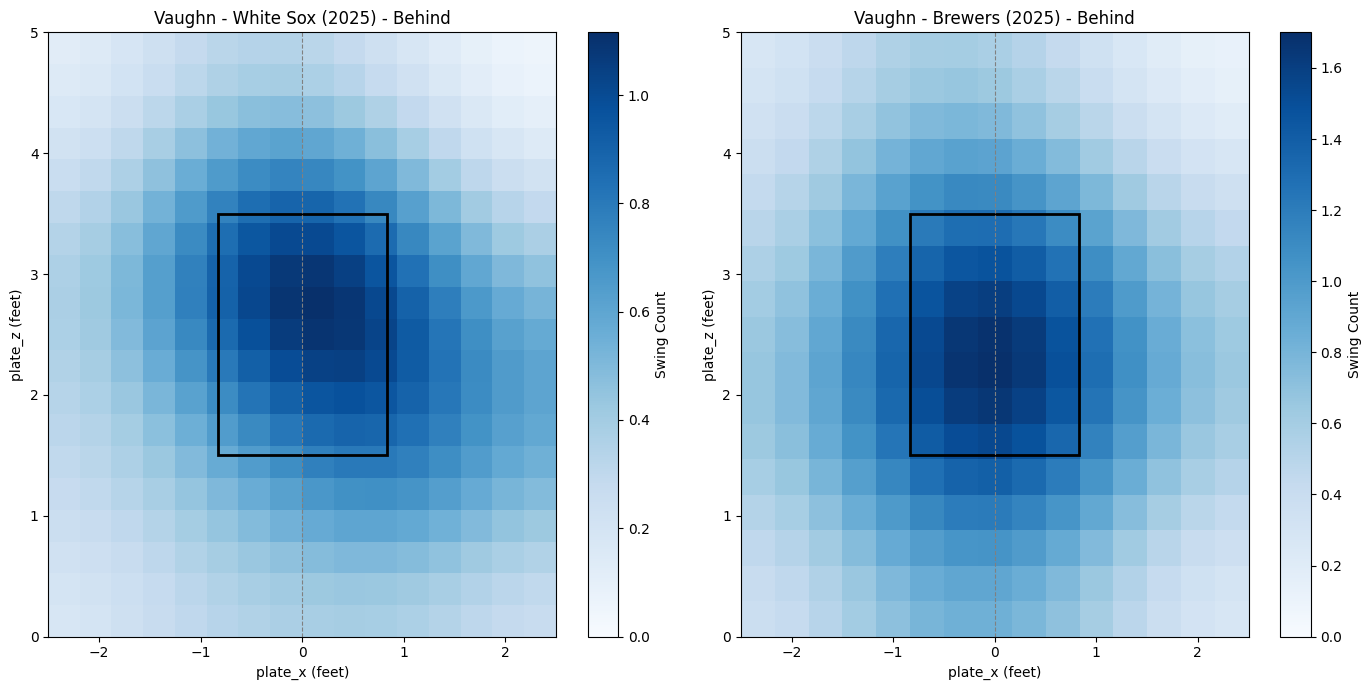

In [ ]:
#visualize swing frequency by location when behind in count with heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

datasets = [
    (vaughn_sox_behind, "Vaughn - White Sox (2025) - Behind"),
    (vaughn_brew_behind, "Vaughn - Brewers (2025) - Behind")
]

x_bins = np.linspace(-2.5, 2.5, 25)
z_bins = np.linspace(0, 5, 25)

for ax, (data, title) in zip(axes, datasets):
    plot_df = data.copy()
    plot_df["x_bin"] = pd.cut(plot_df["plate_x"], bins=x_bins)
    plot_df["z_bin"] = pd.cut(plot_df["plate_z"], bins=z_bins)

    heatmap = plot_df.groupby(["x_bin", "z_bin"], observed=True)["plate_x"].count().unstack().astype(float)

    smoothed = gaussian_filter(heatmap.fillna(0).T.values, sigma=3)

    im = ax.imshow(
        smoothed,
        extent=[-2.5, 2.5, 0, 5],
        origin="lower",
        aspect="auto",
        cmap="Blues",
        vmin=0
    )

    strike_zone = plt.Rectangle(
        (-0.83, 1.5), 1.66, 2.0,
        linewidth=2, edgecolor="black", facecolor="none"
    )
    ax.add_patch(strike_zone)

    plt.colorbar(im, ax=ax, label="Swing Count")
    ax.set_xlabel("plate_x (feet)")
    ax.set_ylabel("plate_z (feet)")
    ax.set_title(title)
    ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

In [ ]:
#get swings with 2 strikes
two_strikes=['0-2','1-2','2-2','3-2']
vaughn_brew_2k=vaughn_brew[vaughn_brew['count'].isin(two_strikes)]
vaughn_sox_2k=vaughn_sox[vaughn_sox['count'].isin(two_strikes)]
vaughn_brew_2k_takes=vaughn_brew_takes[vaughn_brew_takes['count'].isin(two_strikes)]
vaughn_sox_2k_takes=vaughn_sox_takes[vaughn_sox_takes['count'].isin(two_strikes)]

In [ ]:
#create binary variable that signifies a swing or take
vaughn_swings['swing']='1'
vaughn_takes['swing']='0'

In [ ]:
#combine swings with takes and create new dataframes filtering by count leverage
vaughn_all=pd.concat([vaughn_swings,vaughn_takes]).copy()
vaughn_all['count']=vaughn_all['balls'].astype(int).astype(str)+'-'+vaughn_all['strikes'].astype(int).astype(str)
vaughn_all_brew=vaughn_all[vaughn_all['season']=='2025_brew'].copy()
vaughn_all_sox=vaughn_all[vaughn_all['season']=='2025_sox'].copy()
vaughn_all_brew_2k=vaughn_all_brew[vaughn_all_brew['count'].isin(two_strikes)]
vaughn_all_sox_2k=vaughn_all_sox[vaughn_all_sox['count'].isin(two_strikes)]
vaughn_all_brew_ahead=vaughn_all_brew[vaughn_all_brew['count'].isin(ahead_counts)]
vaughn_all_sox_ahead=vaughn_all_sox[vaughn_all_sox['count'].isin(ahead_counts)]
vaughn_all_brew_behind=vaughn_all_brew[vaughn_all_brew['count'].isin(behind_counts)]
vaughn_all_sox_behind=vaughn_all_sox[vaughn_all_sox['count'].isin(behind_counts)]

In [ ]:
#calculate the % of positive and negative xRV swings with 2K
vaughn_swings['count']=vaughn_swings['balls'].astype(int).astype(str)+'-'+vaughn_swings['strikes'].astype(int).astype(str)
vaughn_swings_2k=vaughn_swings[vaughn_swings['count'].isin(two_strikes)].copy()
vaughn_swings_2k["pos_rv"] = vaughn_swings_2k["net_rv"] > 0
vaughn_swings_2k["neg_rv"] = vaughn_swings_2k["net_rv"] < 0

vaughn_swings_pos_neg = vaughn_swings_2k.groupby(["season"]).agg(
    pos_rv=("pos_rv", "sum"),
    neg_rv=("neg_rv", "sum"),
    pitches=("net_rv", "count")
).reset_index()

vaughn_swings_pos_neg["pct_pos"] = (vaughn_swings_pos_neg["pos_rv"] / vaughn_swings_pos_neg["pitches"] * 100).round(1)
vaughn_swings_pos_neg["pct_neg"] = (vaughn_swings_pos_neg["neg_rv"] / vaughn_swings_pos_neg["pitches"] * 100).round(1)
print("Vaughn Swings Positive/Negative xRV% (2K)")
vaughn_swings_pos_neg.sort_values(by="pct_pos",ascending=False)

Vaughn Swings Positive/Negative xRV% (2K)


,season,pos_rv,neg_rv,pitches,pct_pos,pct_neg
4,2025_brew,116,58,174,66.7,33.3
2,2023,241,172,413,58.4,41.6
1,2022,217,172,389,55.8,44.2
3,2024,241,192,433,55.7,44.3
0,2021,168,138,306,54.9,45.1
5,2025_sox,76,68,144,52.8,47.2


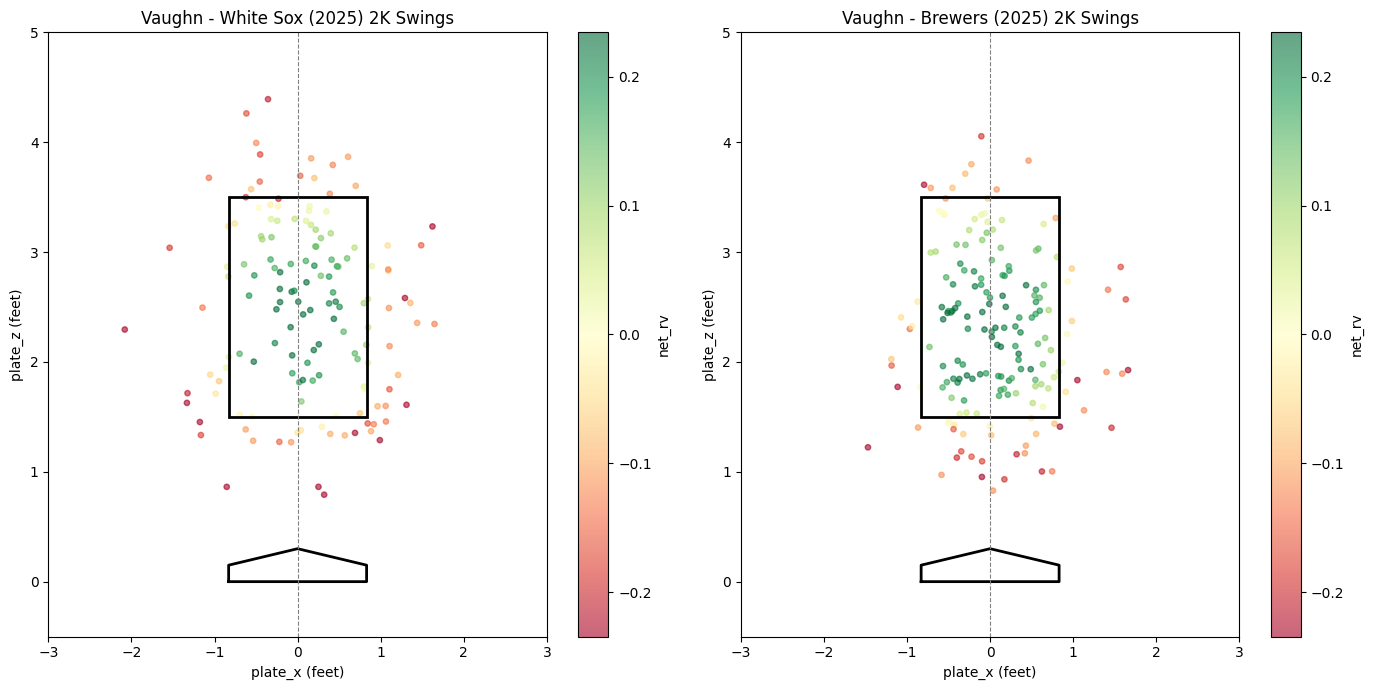

In [ ]:
#visualize all 2K swings by location colored by xRV
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

datasets = [
    (vaughn_swings_2k[vaughn_swings_2k["season"] == "2025_sox"], "Vaughn - White Sox (2025) 2K Swings"),
    (vaughn_swings_2k[vaughn_swings_2k["season"] == "2025_brew"], "Vaughn - Brewers (2025) 2K Swings")
]

for ax, (data, title) in zip(axes, datasets):

    vmax = vaughn_swings["net_rv"].abs().quantile(0.95)  # shared scale

    sc = ax.scatter(
        data["plate_x"], data["plate_z"],
        c=data["net_rv"],
        cmap="RdYlGn",
        vmin=-vmax,
        vmax=vmax,
        alpha=0.6,
        s=15
    )

    strike_zone = plt.Rectangle(
        (-0.83, 1.5), 1.66, 2.0,
        linewidth=2, edgecolor="black", facecolor="none"
    )
    ax.add_patch(strike_zone)

    plate_x = [-0.83, 0.83, 0.83, 0, -0.83,-0.83]
    plate_z = [0.0, 0.0, 0.15, 0.3, 0.15,0.0]
    ax.plot(plate_x, plate_z, color="black", linewidth=2)

    plt.colorbar(sc, ax=ax, label="net_rv")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-0.5, 5)
    ax.set_xlabel("plate_x (feet)")
    ax.set_ylabel("plate_z (feet)")
    ax.set_title(title)
    ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

In [ ]:
#get positive and negative swing xRV% ahead in the count
vaughn_swings_ahead=vaughn_swings[vaughn_swings['count'].isin(ahead_counts)].copy()
vaughn_swings_ahead["pos_rv"] = vaughn_swings_ahead["net_rv"] > 0
vaughn_swings_ahead["neg_rv"] = vaughn_swings_ahead["net_rv"] < 0

vaughn_swings_pos_neg = vaughn_swings_ahead.groupby(["season"]).agg(
    pos_rv=("pos_rv", "sum"),
    neg_rv=("neg_rv", "sum"),
    pitches=("net_rv", "count")
).reset_index()

vaughn_swings_pos_neg["pct_pos"] = (vaughn_swings_pos_neg["pos_rv"] / vaughn_swings_pos_neg["pitches"] * 100).round(1)
vaughn_swings_pos_neg["pct_neg"] = (vaughn_swings_pos_neg["neg_rv"] / vaughn_swings_pos_neg["pitches"] * 100).round(1)

vaughn_swings_pos_neg.sort_values(by="pct_pos",ascending=False)

,season,pos_rv,neg_rv,pitches,pct_pos,pct_neg
0,2021,122,46,168,72.6,27.4
4,2025_brew,65,25,90,72.2,27.8
5,2025_sox,57,25,82,69.5,30.5
3,2024,150,71,221,67.9,32.1
2,2023,119,70,189,63.0,37.0
1,2022,106,63,169,62.7,37.3


In [ ]:
#get positive and negative swing xRV% behind in the count
vaughn_swings_behind=vaughn_swings[vaughn_swings['count'].isin(behind_counts)].copy()
vaughn_swings_behind["pos_rv"] = vaughn_swings_behind["net_rv"] > 0
vaughn_swings_behind["neg_rv"] = vaughn_swings_behind["net_rv"] < 0

vaughn_swings_pos_neg = vaughn_swings_behind.groupby(["season"]).agg(
    pos_rv=("pos_rv", "sum"),
    neg_rv=("neg_rv", "sum"),
    pitches=("net_rv", "count")
).reset_index()

vaughn_swings_pos_neg["pct_pos"] = (vaughn_swings_pos_neg["pos_rv"] / vaughn_swings_pos_neg["pitches"] * 100).round(1)
vaughn_swings_pos_neg["pct_neg"] = (vaughn_swings_pos_neg["neg_rv"] / vaughn_swings_pos_neg["pitches"] * 100).round(1)

vaughn_swings_pos_neg.sort_values(by="pct_pos",ascending=False)

,season,pos_rv,neg_rv,pitches,pct_pos,pct_neg
4,2025_brew,138,70,208,66.3,33.7
3,2024,295,226,521,56.6,43.4
1,2022,254,203,457,55.6,44.4
2,2023,284,230,514,55.3,44.7
5,2025_sox,84,74,158,53.2,46.8
0,2021,178,177,355,50.1,49.9


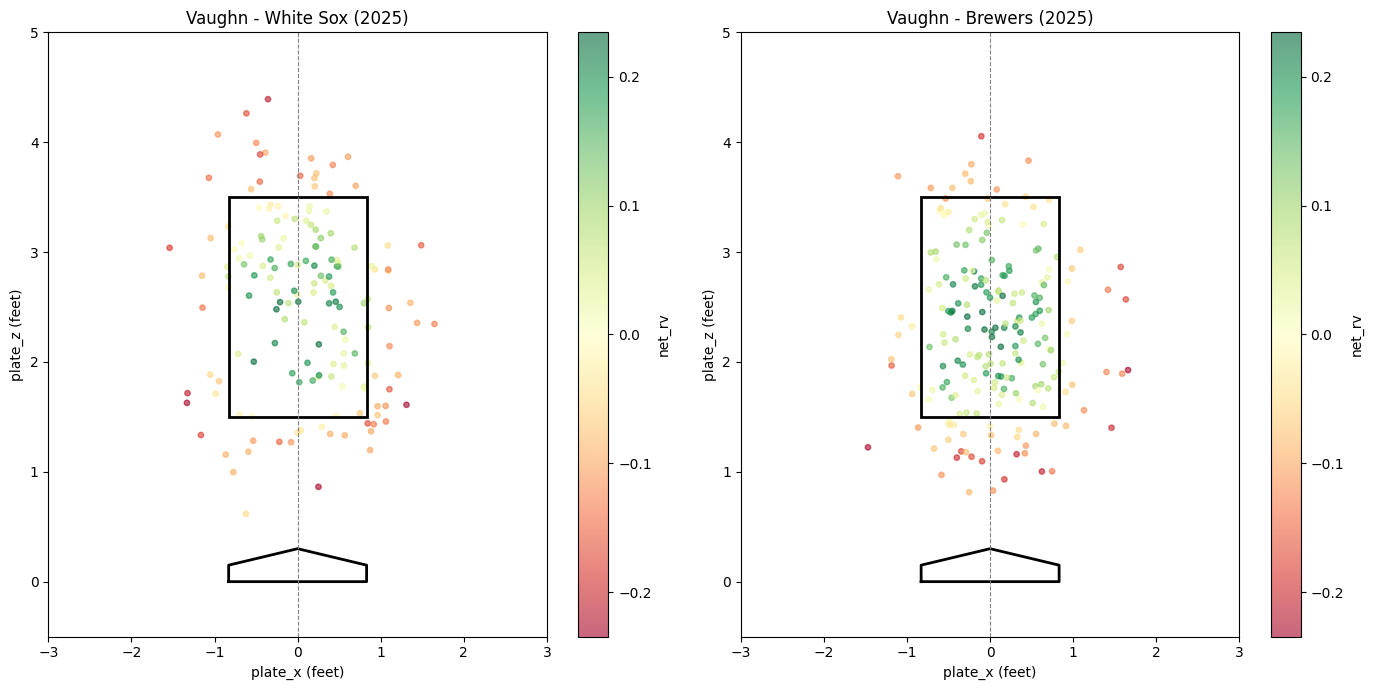

In [ ]:
#visualize all swings behind in the count by location colored by xRV
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

datasets = [
    (vaughn_swings_behind[vaughn_swings_behind["season"] == "2025_sox"], "Vaughn - White Sox (2025)"),
    (vaughn_swings_behind[vaughn_swings_behind["season"] == "2025_brew"], "Vaughn - Brewers (2025)")
]

for ax, (data, title) in zip(axes, datasets):

    vmax = vaughn_swings["net_rv"].abs().quantile(0.95)  # shared scale

    sc = ax.scatter(
        data["plate_x"], data["plate_z"],
        c=data["net_rv"],
        cmap="RdYlGn",
        vmin=-vmax,
        vmax=vmax,
        alpha=0.6,
        s=15
    )

    strike_zone = plt.Rectangle(
        (-0.83, 1.5), 1.66, 2.0,
        linewidth=2, edgecolor="black", facecolor="none"
    )
    ax.add_patch(strike_zone)

    plate_x = [-0.83, 0.83, 0.83, 0, -0.83,-0.83]
    plate_z = [0.0, 0.0, 0.15, 0.3, 0.15,0.0]
    ax.plot(plate_x, plate_z, color="black", linewidth=2)

    plt.colorbar(sc, ax=ax, label="net_rv")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-0.5, 5)
    ax.set_xlabel("plate_x (feet)")
    ax.set_ylabel("plate_z (feet)")
    ax.set_title(title)
    ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

In [ ]:
#get net swing xRV/100 for each season including the split season for 2K swings
vaughn_swings_2k_rv = vaughn_swings_2k.groupby(["batter",'season']).agg(
    net_rv=("net_rv", "sum"),
    pitches=("net_rv", "count")
).reset_index()

vaughn_swings_2k_rv["net_rv_per_100"] = (vaughn_swings_2k_rv["net_rv"] / vaughn_swings_2k_rv["pitches"]) * 100

In [ ]:
#show ranked leaderboard
print("Vaughn Swing RV by Season (2 Strikes)")
vaughn_swings_2k_rv.sort_values(by="net_rv_per_100",ascending=False)

Vaughn Swing RV by Season (2 Strikes)


,batter,season,net_rv,pitches,net_rv_per_100
4,683734,2025_brew,11.170660,174,6.419920
2,683734,2023,13.602766,413,3.293648
1,683734,2022,12.091041,389,3.108237
3,683734,2024,8.362386,433,1.931267
0,683734,2021,3.980360,306,1.300771
5,683734,2025_sox,1.517125,144,1.053559


In [ ]:
#get net swing xRV/100 for each season including the split season for swings ahead in the count
vaughn_swings_ahead_rv = vaughn_swings_ahead.groupby(["batter",'season']).agg(
    net_rv=("net_rv", "sum"),
    pitches=("net_rv", "count")
).reset_index()

vaughn_swings_ahead_rv["net_rv_per_100"] = (vaughn_swings_ahead_rv["net_rv"] / vaughn_swings_ahead_rv["pitches"]) * 100

In [ ]:
#show ranked leaderboard
print("Vaughn Swing RV by Season (Ahead in Count)")
vaughn_swings_ahead_rv.sort_values(by="net_rv_per_100",ascending=False)

Vaughn Swing RV by Season (Ahead in Count)


,batter,season,net_rv,pitches,net_rv_per_100
5,683734,2025_sox,1.622757,82,1.978972
4,683734,2025_brew,1.280874,90,1.423194
3,683734,2024,2.989422,221,1.352680
0,683734,2021,2.020319,168,1.202571
2,683734,2023,1.797325,189,0.950966
1,683734,2022,0.920964,169,0.544949


In [ ]:
#get net swing xRV/100 for each season including the split season for swings behind in the count
vaughn_swings_behind_rv = vaughn_swings_behind.groupby(["batter",'season']).agg(
    net_rv=("net_rv", "sum"),
    pitches=("net_rv", "count")
).reset_index()

vaughn_swings_behind_rv["net_rv_per_100"] = (vaughn_swings_behind_rv["net_rv"] / vaughn_swings_behind_rv["pitches"]) * 100

In [ ]:
#show ranked leaderboard
vaughn_swings_behind_rv.sort_values(by="net_rv_per_100",ascending=False)

,batter,season,net_rv,pitches,net_rv_per_100
4,683734,2025_brew,8.338913,208,4.009093
1,683734,2022,9.410732,457,2.059241
3,683734,2024,10.203502,521,1.958446
2,683734,2023,9.080535,514,1.766641
5,683734,2025_sox,1.209326,158,0.765396
0,683734,2021,1.057367,355,0.297850
